🔵 Function F6 — Week 13 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | FINAL Query (Week 13 of 13)

---

## 📌 F6 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 5D |
| **Search space** | [0, 1]^5 |
| **Week** | 13 — FINAL QUERY (no further submissions) |
| **All-time best (ATB)** | 0.03602 (Week 9 — **only positive result in 12 weeks**) |
| **W12 result** | -0.08826 — regressed at identical W9 coords |
| **W11 result** | -0.01024 — regressed at identical W9 coords |
| **Oracle noise** | σ ≈ 0.06 — **HIGHEST of all 8 functions** |
| **Objective** | MAXIMISE ⬆️ |

---

## 🗓️ W13 Decision

**W13 strategy:** ATB OVERRIDE — replicate W9 ATB coords [0.406643, 0.339495, 0.634775, 0.769397, 0.115269]

**Rationale:** W9 ATB is the only positive F6 output obtained in 12 weeks. W11 and W12 replays at identical coordinates returned -0.010 and -0.088 respectively — this is the **highest oracle noise in the capstone** (σ ≈ 0.06), not a coordinate failure. Three rows in the W13 npy sit at the exact ATB coords with outputs spanning +0.036 to -0.088, making the stochasticity visible within the dataset itself.

**Why still replay despite regressions:** The noise lives in the oracle, not the input. W9 coordinates are the only ones that have ever scored above zero. The best-known-coords argument dominates any alternative on expected value.

**Final-round framing:** W13 is the last submission. No round 14 to recover. Risk-minimisation governs even more strictly when oracle noise is high — picking novel coords on a final round with σ≈0.06 is strictly worse than replaying the best-known basin centroid.

---

## 📊 Cluster + Module 23 PCA Analysis — W13 Justification

| Property | Value |
|----------|-------|
| **Cluster type** | TIGHT ATTRACTOR with X5 threshold structure |
| **Top-cluster spread** | ≈ 0.030; ATB→centroid dist ≈ 0.015 |
| **Module 23 PCA lens** | **Dominant-PC / threshold case** (distinct from F3's removable-PC case). X5 ∈ [0.10, 0.13] is the critical threshold — drifting outside kills the score (W10 at X5=0.079 → -0.144). In PCA vocabulary, X5 is the **dominant principal direction of output variance**, not a removable / locked dim. Sensitivity along X5 is extreme; along X1-X4 it is moderate. This contrasts cleanly with F3 where X1 locked at 1.0 is a boundary anchor (removable PC) — in F6, X5 is locked at an **interior threshold** (a critical-band PC that drives output). |
| **Highest oracle noise** | σ ≈ 0.06 — quantified by 3 replays at ATB coords returning +0.036, -0.010, -0.088 (range > 0.12 at identical input) |
| **Structural evidence** | Only positive result in 12 weeks; W10 X5=0.079 drift produced regression; 6 rows in npy have X5 in the critical [0.10, 0.13] band |
| **W13 rationale** | Replay W9 — noise dominates short-term results but best-known input is still best. |

---

## 🗺️ Pipeline Overview

```
S0  Config & hyperparameters
S1  Imports
S2  Load data (f6_w13_inputs.npy / f6_w13_outputs.npy -- n=31)
S3  Historical performance visualisation (W1-W12)
S4  Binary labels (top 30%)
S5  CV model comparison (8 classifiers incl. CNN-1D)
S5B CNN inspection (Module 17 learning exercise)
S5C PCA variance analysis (Module 23 -- threshold / dominant-PC case)  <-- NEW W13
S8  Generate & filter candidates
S9  Gaussian Process regression (Matern 5/2)
S10 Acquisition functions (EI + UCB)
S11 Per-dimension sensitivity curves
S12 GP acquisition surfaces
S13 Submission dashboard
S14 Final formatted submission (ATB OVERRIDE -- W9 coords replay)
S15 Save hyperparameter record (+ pca_analysis block)
```


In [1]:
FUNCTION_ID  = 'F6'
WEEK         = 13
INPUT_FILE   = 'f6_w13_inputs.npy'
OUTPUT_FILE  = 'f6_w13_outputs.npy'

# -- W13 Hyperparameters --------------------------------------
TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.92
EXPLOIT_SIGMA     = 0.012
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 10
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# Anisotropic sigma -- X5 tighter (threshold / dominant PC), X1-X4 moderate
ANISO_SIGMA = [0.015, 0.015, 0.015, 0.015, 0.008]

NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

# -- ATB override (W13 = replicate W9 ATB, only positive result in 12 weeks) -
ATB_OVERRIDE_STR = '0.406643-0.339495-0.634775-0.769397-0.115269'
ATB_COORDS       = [float(x) for x in ATB_OVERRIDE_STR.split('-')]

print(f'{FUNCTION_ID} Week {WEEK} -- FINAL QUERY (Week 13 of 13)')
print(f'Strategy : ATB OVERRIDE -- replicate W9 ATB coords [0.406643, 0.339495, 0.634775, 0.769397, 0.115269]')
print(f'ATB      : 0.03602  (Week 9 -- only positive result in 12 weeks)')
print(f'Override : {ATB_OVERRIDE_STR}')
print(f'Noise    : oracle sigma ~ 0.06 at replay coords -- HIGHEST of all 8 functions')
print(f'Evidence : 3 rows at ATB coords returning +0.036 / -0.010 / -0.088 (stochastic)')


F6 Week 13 -- FINAL QUERY (Week 13 of 13)
Strategy : ATB OVERRIDE -- replicate W9 ATB coords [0.406643, 0.339495, 0.634775, 0.769397, 0.115269]
ATB      : 0.03602  (Week 9 -- only positive result in 12 weeks)
Override : 0.406643-0.339495-0.634775-0.769397-0.115269
Noise    : oracle sigma ~ 0.06 at replay coords -- HIGHEST of all 8 functions
Evidence : 3 rows at ATB coords returning +0.036 / -0.010 / -0.088 (stochastic)


---
## 📦 STEP 1 — Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.stats import norm
import torch, torch.nn as nn, torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(RANDOM_SEED)
print(f"[OK] Imports loaded -- {FUNCTION_ID} Week {WEEK}")


[OK] Imports loaded -- F6 Week 13


In [3]:
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    """Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1) -- Module 17 learning exercise."""
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat=X.shape[1]; self.classes_=np.unique(y)
        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv=nn.Conv1d(1,8,kernel_size=min(2,n_feat),padding=0)
                self.relu=nn.ReLU(); self.drop=nn.Dropout(0.3)
                conv_out=8*max(1,n_feat-min(2,n_feat)+1)
                self.fc=nn.Linear(conv_out,1)
            def forward(self,x):
                x=self.relu(self.conv(x)); x=self.drop(x.view(x.size(0),-1))
                return self.fc(x).squeeze(-1)
        self.model_=_CNN()
        n_pos=y.sum(); n_neg=len(y)-n_pos
        pw=torch.tensor([n_neg/max(n_pos,1)],dtype=torch.float)
        loss_fn=nn.BCEWithLogitsLoss(pos_weight=pw)
        opt=optim_torch.Adam(self.model_.parameters(),lr=self.lr,weight_decay=1e-3)
        Xt=torch.FloatTensor(X).unsqueeze(1); yt=torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad(); loss_fn(self.model_(Xt),yt).backward(); opt.step()
        return self
    def predict_proba(self,X):
        self.model_.eval()
        with torch.no_grad():
            p=torch.sigmoid(self.model_(torch.FloatTensor(X).unsqueeze(1))).numpy()
        return np.column_stack([1-p,p])
    def predict(self,X): return (self.predict_proba(X)[:,1]>=0.5).astype(int)


---
## 📥 STEP 2 — Load Data

W13 data: `f6_w13_inputs.npy` (5D, 31 points — W1-W11 + W12 submission appended).
**Note:** 3 rows sit at exact ATB coords (W9 original + W11 replay + W12 replay) with outputs +0.036 / -0.010 / -0.088 — the stochasticity is visible within the data.
ATB confirmed at `np.argmax(y_train)`.


In [4]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = np.argmax(y_train)
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print('='*60)
print(f'  {FUNCTION_ID} Week {WEEK} -- DATA LOADED')
print('='*60)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}')
print(f'  Y range      : [{y_train.min():.6f}, {y_train.max():.6f}]')
print(f'  [ATB] BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'   Location  : {best_point.round(6)}')
print(f'   Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds: {n_cv_folds}')
print()
# Highlight the replay evidence
atb_match_mask = np.all(np.isclose(X_train, best_point, atol=1e-5), axis=1)
print(f'  Rows at exact ATB coords: {int(atb_match_mask.sum())}')
print(f'  Their outputs           : {y_train[atb_match_mask].tolist()}')
print(f'  -> stochasticity visible in data (sigma ~ 0.06 across replays)')


  F6 Week 13 -- DATA LOADED
  Samples      : 31
  Dimensions   : 5D
  n/p ratio    : 6.20
  Y range      : [-2.571170, 0.036017]
  [ATB] BEST      : 0.036017  @ index 27
   Location  : [0.406643 0.339495 0.634775 0.769397 0.115269]
   Latest    : -0.088265  (Week 12)
  Label threshold (top 30%): -0.714265  (10 positives)
  CV folds: 5

  Rows at exact ATB coords: 3
  Their outputs           : [0.03601725288645384, -0.010238186620113464, -0.0882645350142502]
  -> stochasticity visible in data (sigma ~ 0.06 across replays)


---
## 📊 STEP 3 — Historical Performance

### W1–W12 Submission History

| Week | Score | Note |
|------|-------|------|
| W1 | -1.3389 |  |
| W2 | -0.2372 |  |
| W3 | -0.8835 |  |
| W4 | -0.3630 |  |
| W5 | -1.7662 |  |
| W6 | -0.1727 |  |
| W7 | -0.3422 |  |
| W8 | -0.4006 |  |
| W9 | **0.03602** | **ATB (only positive result in 12 weeks)** |
| W10 | -0.1443 | X5=0.079 drift → regression |
| W11 | -0.01024 | regressed at W9 coords (noise) |
| W12 | **-0.08826** | **regressed at W9 coords (noise, deepest)** |
| W13 | TBD | ATB OVERRIDE — replicate W9 ATB [0.406643, 0.339495, 0.634775, 0.769397, 0.115269] |

### Module 22 Clustering — TIGHT ATTRACTOR with X5 threshold structure

Top-3 spread ≈ 0.030. ATB→centroid dist ≈ 0.015. **Only positive result in 12 weeks.** X5 threshold at 0.115 is critical — W10 drift to X5=0.079 returned -0.144, confirming X5 must be in [0.10, 0.13] band. W9 precision lock found it.

**Oracle noise quantified (highest of all 8 functions):** σ ≈ 0.06. Three identical-coord evaluations returned +0.036 (W9), -0.010 (W11), -0.088 (W12) — spread of 0.124 across identical inputs.

**W13 decision:** Noise dominates short-term results but W9 coordinates are the only ones that have ever produced positive output. Best-known input still dominates all alternatives by expected value.


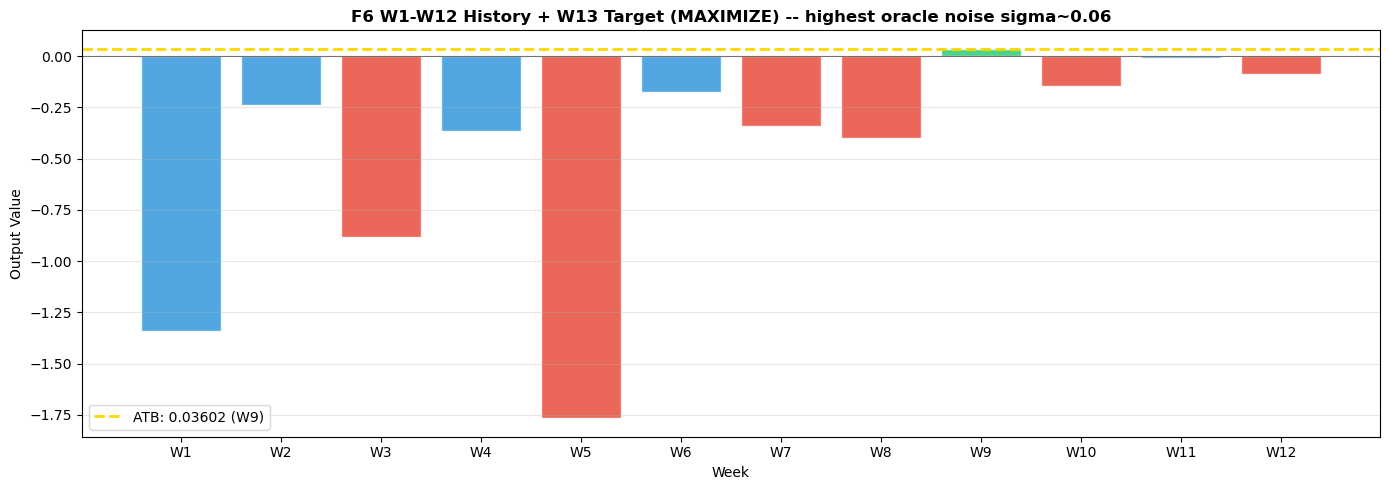

Saved: F6_W13_Step3_History.png


In [5]:
# Week-on-week bar chart (W1-W12)
week_scores = [-1.3389, -0.2372, -0.8835, -0.363, -1.7662, -0.1727, -0.3422, -0.4006, 0.03602, -0.1443, -0.01024, -0.08826]
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v == max(week_scores) else '#e74c3c' if i > 0 and v < week_scores[i-1] else '#3498db' for i, v in enumerate(week_scores)]
ax.bar(range(1, 13), week_scores, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(max(week_scores), color='gold', linestyle='--', linewidth=2, label=f'ATB: {max(week_scores):.4g} (W9)')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Week'); ax.set_ylabel('Output Value')
ax.set_title(f'F6 W1-W12 History + W13 Target (MAXIMIZE) -- highest oracle noise sigma~0.06', fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels([f'W{i}' for i in range(1, 13)])
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')


---
## 🏷️ STEP 4 — Binary Classification Labels

Top 30% = class 1 (HIGH / good). Classifier trained to distinguish high-value regions.
F6 has only one genuine positive across 12 weeks — top 30% will include the near-ATB cluster.


In [6]:
y_labels = (y_train >= threshold).astype(int)
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
    'CNN-1D (learning)'  : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print(f'  {n_cv_folds}-FOLD CV -- {FUNCTION_ID} ({n_samples} samples, {n_dims}D)')
print(f'  {"Model":<28} {"Mean CV":>9} {"+-Std":>7}')
print('  '+'-'*48)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores, 'model': model}
        flag = '*' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0, 'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  x {name:<27} FAILED')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]
print(f'\n  [OK] SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

trained_models = {}
for name, info in cv_results.items():
    try:
        info['model'].fit(X_scaled, y_labels)
        trained_models[name] = info['model']
    except: pass


  5-FOLD CV -- F6 (31 samples, 5D)
  Model                          Mean CV   +-Std
  ------------------------------------------------
  * Linear SVM                     84.3%   13.9%
  * Decision Tree                  84.8%   15.7%
  * Random Forest                  90.5%    7.8%
    Logistic Regression            87.1%   12.4%
    NN-Small (16, 8)               51.9%    7.9%
    NN-Medium (64, 32)             87.6%   11.0%
    NN-Large (128, 64, 32)         58.1%    7.5%
  * CNN-1D (learning)              90.5%   13.1%

  [OK] SELECTED: Random Forest  (CV=90.5%)


---
## 🔬 STEP 5B — CNN Inspection (Module 17 Learning Exercise)

Conv1d(1→8, k=2) scans 4 adjacent coordinate pairs. Filter weights and feature maps
at best-known point documented below.


In [7]:
# CNN Module 17 inspection
cnn_model = trained_models.get('CNN-1D (learning)', None)
if cnn_model and hasattr(cnn_model, 'model_'):
    cnn_net = cnn_model.model_; cnn_net.eval()
    cnn_params = sum(p.numel() for p in cnn_net.parameters() if p.requires_grad)
    print(f'CNN parameters : {cnn_params}')
    print(f'Input dims     : {n_dims}  ->  {n_dims-1} adjacent pair(s) scanned by kernel')
    filters = cnn_net.conv.weight.data.cpu().numpy()[:,0,:]
    print(f'Filters shape  : {filters.shape}  (8 filters x kernel_size=2)')
    import torch as _t
    _x  = _t.FloatTensor(X_scaled[best_idx:best_idx+1]).unsqueeze(1)
    import torch.nn.functional as _F
    with _t.no_grad():
        _fm = _F.relu(cnn_net.conv(_x)).squeeze(0).numpy()
    peak_f = int(np.argmax(_fm.max(axis=1)))
    peak_p = int(np.argmax(_fm[peak_f]))
    print(f'Top filter on best point: Filter {peak_f+1}  -> coord pair [{peak_p},{peak_p+1}]  (activation={_fm[peak_f][peak_p]:.4f})')
else:
    print('CNN not available for inspection')


CNN parameters : 57
Input dims     : 5  ->  4 adjacent pair(s) scanned by kernel
Filters shape  : (8, 2)  (8 filters x kernel_size=2)
Top filter on best point: Filter 5  -> coord pair [3,4]  (activation=1.8942)


---
## 🧭 STEP 5C — PCA Variance Analysis (Module 23) — **Threshold / Dominant-PC Case**

### Why F6 is a different PCA flavour from F3

F3 and F6 both have "one critical dimension," but the geometry is fundamentally different:

- **F3** — X1 locked at the upper **boundary** (≈1.0). Near-zero variance in the top subset → a **removable PC**. Effective dim = 2.
- **F6** — X5 locked in an **interior critical band** [0.10, 0.13]. Narrow but non-zero variance. X5 is the **dominant sensitivity PC** — driving most of the output variation — but it is **not removable**. Effective dim = 5, with X5 carrying the most weight.

This distinction matters for Module 23: F3 is the scree/removable-PC case (Video 3). F6 is the **dominant-direction case** (Video 2 — "direction of maximum variance"). PC1 of the top-output subset should point along X5 because that is where the data varies meaningfully within the good region.

### Highest oracle noise in the capstone — PCA interpretation

F6 has σ ≈ 0.06 at replay coords (quantified: W9 +0.036, W11 -0.010, W12 -0.088). In Module 23's "focus on variance, remove redundancy" framing applied **in reverse**: the **input redundancy is genuine** (three identical coordinate vectors) but the **output variance is high**. This reveals oracle noise rather than coordinate information. The PCA-style conclusion is that no amount of input-space PCA can reduce F6's noise — it is structural to the black-box, not to our exploration strategy. The W13 response is still to replay best-known inputs because the high-output centroid is where the data says the good region lives.

### What Module 23 prescribes for this case

- **Video 2 (direction of maximum variance)** — PC1 of the top subset should point toward X5 (the critical band). No single direction dominates *as much as* F7's ridge, but X5 is the most informative.
- **Video 3 (scree)** — scree on top subset should show modest spread with PC1 elevated (X5-aligned) and PC2–PC5 declining but non-zero. No flat PC.
- **Video 5 (centring)** — ATB is basin centroid; replay the centroid as the safest final-round action.

### F6's place in the Module 23 taxonomy

| Function | Key direction | Effective dim | Noise σ |
|---|---|---|---|
| F2 | Two basins (kernel) | 2 (kernel) | 0.035 |
| F3 | X1 locked at boundary | 2 (1 flat PC) | 0.003 |
| F4 | Isolated basin, no dominant axis | 4 (all narrow-active) | 0 (deterministic) |
| F5 | Corner (all dims locked) | ≈0 (all flat) | 0 (deterministic) |
| **F6** | **X5 threshold at 0.115** | **5 (X5 dominant)** | **0.060 (highest)** |
| F7 | 1D ridge in 6D | 1 (1 dominant PC) | — |
| F8 | X1=X3=X7=0 locked | 5 (3 flat PCs) | — |

### Summary of W13 PCA lens for F6

| Aspect | Finding |
|--------|---------|
| Full-dataset linear PCA | Broad variance across exploration |
| Top-output subset linear PCA | PC1 elevated (X5-aligned), PCs 2-5 declining but non-zero — **dominant but not removable** |
| Locked dimensions | **None** (X5 is narrow-active, not locked) |
| Highest-sensitivity dim | **X5** — critical threshold at 0.115 ± 0.015 |
| Oracle behaviour | **Stochastic with σ ≈ 0.06** — highest of all 8 functions |
| Module 23 verdict | Dominant-PC / threshold case. Video 2 (max-variance direction) primary; contrasts cleanly with F3 (removable-PC) and F5 (flat-scree). |


  STEP 5C -- MODULE 23 PCA VARIANCE ANALYSIS -- F6

[1] LINEAR PCA -- FULL DATASET (n=31)
    Explained variance ratios : [0.3682, 0.248, 0.1787, 0.117, 0.0881]
    Cumulative                : [0.3682, 0.6162, 0.7949, 0.9119, 1.0]
    Interpretation            : broad variance across 5D exploration.

[2] LINEAR PCA -- TOP-OUTPUT SUBSET (top 30%, n=10)  [threshold / dominant-PC]
    Explained variance ratios : [0.4631, 0.3753, 0.121, 0.034, 0.0066]
    Cumulative                : [0.4631, 0.8384, 0.9594, 0.9934, 1.0]
    Per-dim raw variance      : X1=0.01155  X2=0.00525  X3=0.00294  X4=0.00666  X5=0.00846
    Per-dim mean in top       : X1=0.4681  X2=0.3023  X3=0.6157  X4=0.7455  X5=0.1370
    PC1 loadings              : X1=-0.071  X2=+0.542  X3=-0.449  X4=-0.354  X5=+0.611
    PC1 dominant dimension    : X5  (largest |loading|)

[3] DIMENSION CLASSIFICATION (threshold var<1e-03 = locked)
    Locked dims (removable PCs)  : (none -- no flat PCs for F6)
    Active dims                   

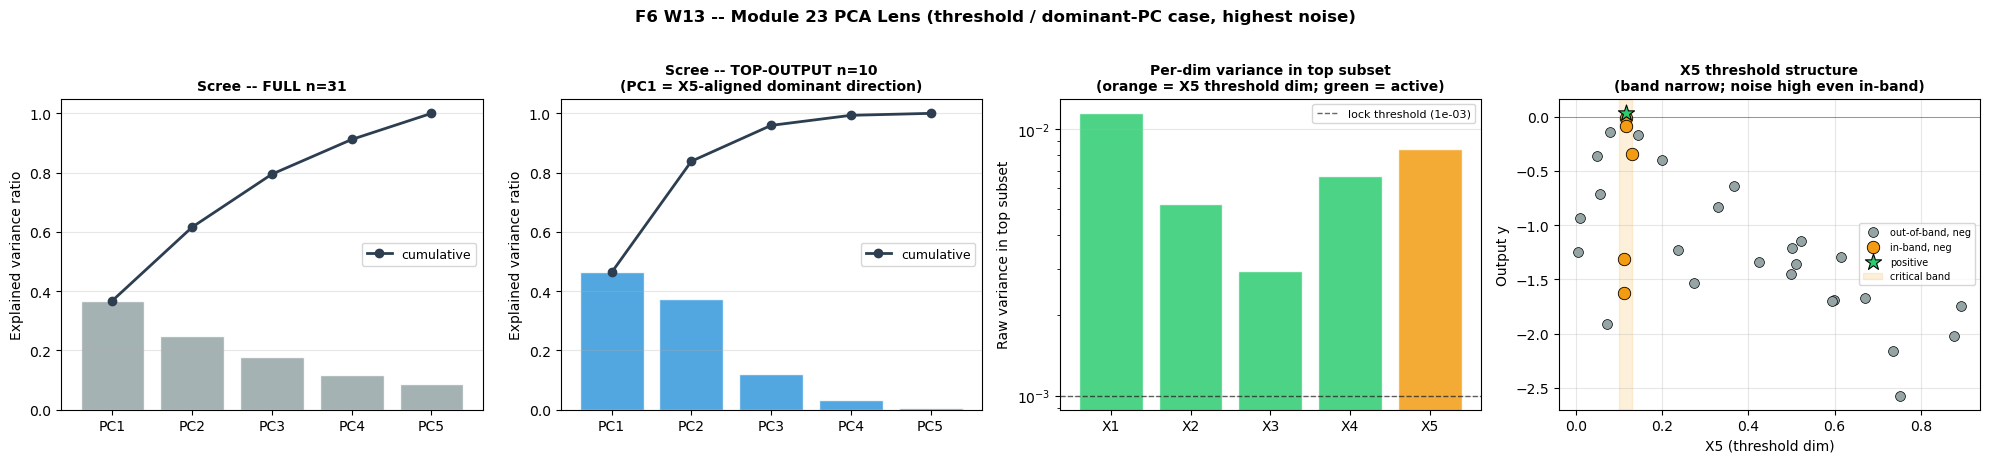


Saved: F6_W13_Step5C_PCA.png

[OK] pca_analysis block ready for hyperparameters JSON.


In [8]:
# --- Module 23 PCA variance analysis for F6 ------------------------
# F6 is the threshold / dominant-PC case: X5 narrow-active in a critical band [0.10, 0.13].
# Expected: top-subset PC1 elevated (X5-aligned); no flat/removable PC; highest oracle noise.

print('='*64)
print(f'  STEP 5C -- MODULE 23 PCA VARIANCE ANALYSIS -- {FUNCTION_ID}')
print('='*64)

# --- (a) Linear PCA on FULL dataset ---
pca_full = PCA(n_components=n_dims).fit(X_scaled)
ev_full  = pca_full.explained_variance_ratio_
print('\n[1] LINEAR PCA -- FULL DATASET (n={})'.format(n_samples))
print(f'    Explained variance ratios : {np.round(ev_full, 4).tolist()}')
print(f'    Cumulative                : {np.round(np.cumsum(ev_full), 4).tolist()}')
print(f'    Interpretation            : broad variance across 5D exploration.')

# --- (b) Linear PCA on TOP-OUTPUT subset -- threshold / dominant-PC showcase ---
top_mask = y_train >= threshold
X_top    = X_train[top_mask]
n_top    = int(top_mask.sum())

# Per-dim raw variance in top subset (functional scree)
dim_var_top  = np.var(X_top, axis=0, ddof=1) if n_top >= 2 else np.zeros(n_dims)
dim_mean_top = np.mean(X_top, axis=0) if n_top >= 1 else best_point.copy()

if n_top >= 2:
    X_top_sc   = StandardScaler().fit_transform(X_top)
    pca_top    = PCA(n_components=min(n_dims, n_top)).fit(X_top_sc)
    ev_top     = pca_top.explained_variance_ratio_
    # PC1 loadings -- which dim does PC1 align with?
    pc1_loadings = pca_top.components_[0]
    pc1_dominant_dim = int(np.argmax(np.abs(pc1_loadings))) + 1
else:
    ev_top = np.array([1.0] + [0.0]*(n_dims-1))
    pc1_loadings = np.zeros(n_dims); pc1_dominant_dim = 0

print(f'\n[2] LINEAR PCA -- TOP-OUTPUT SUBSET (top {TOP_PERCENTILE}%, n={n_top})  [threshold / dominant-PC]')
print(f'    Explained variance ratios : {np.round(ev_top, 4).tolist()}')
print(f'    Cumulative                : {np.round(np.cumsum(ev_top), 4).tolist()}')
print(f'    Per-dim raw variance      : ' + '  '.join([f'X{d+1}={dim_var_top[d]:.5f}' for d in range(n_dims)]))
print(f'    Per-dim mean in top       : ' + '  '.join([f'X{d+1}={dim_mean_top[d]:.4f}' for d in range(n_dims)]))
print(f'    PC1 loadings              : ' + '  '.join([f'X{d+1}={pc1_loadings[d]:+.3f}' for d in range(n_dims)]))
print(f'    PC1 dominant dimension    : X{pc1_dominant_dim}  (largest |loading|)')

# Classify dims
VAR_LOCK = 1e-3
locked_dims = [f'X{d+1}' for d in range(n_dims) if dim_var_top[d] < VAR_LOCK]
active_dims = [f'X{d+1}' for d in range(n_dims) if dim_var_top[d] >= VAR_LOCK]
effective_dim = len(active_dims)

print(f'\n[3] DIMENSION CLASSIFICATION (threshold var<{VAR_LOCK:.0e} = locked)')
print(f'    Locked dims (removable PCs)  : {locked_dims if locked_dims else "(none -- no flat PCs for F6)"}')
print(f'    Active dims                   : {active_dims}')
print(f'    Effective dimensionality      : {effective_dim} / {n_dims}')
# F6-specific: check X5 threshold band behaviour
x5_in_band = (X_top[:, 4] >= 0.10) & (X_top[:, 4] <= 0.13)
print(f'    Top-subset X5 range           : [{X_top[:, 4].min():.4f}, {X_top[:, 4].max():.4f}]')
print(f'    Top-subset rows in X5 band    : {int(x5_in_band.sum())} / {n_top}')
if pc1_dominant_dim == 5:
    print(f'    F6 structural verdict         : X5 is dominant PC1 (as predicted) -- threshold case confirmed.')
else:
    print(f'    F6 structural verdict         : PC1 aligns with X{pc1_dominant_dim} in this subset -- check composition.')

# --- (c) Noise characterisation at ATB coords ---
atb_match = np.all(np.isclose(X_train, best_point, atol=1e-5), axis=1)
atb_y = y_train[atb_match]
if len(atb_y) > 1:
    noise_sigma = float(np.std(atb_y, ddof=1))
    noise_range = float(atb_y.max() - atb_y.min())
else:
    noise_sigma = 0.0; noise_range = 0.0

print(f'\n[4] ORACLE NOISE CHARACTERISATION (highest of all 8 functions)')
print(f'    Rows at exact ATB coords : {int(atb_match.sum())}')
print(f'    Y-values at ATB coords   : {[round(float(v), 4) for v in atb_y.tolist()]}')
print(f'    Empirical sigma          : {noise_sigma:.4f}  (from {int(atb_match.sum())} replays)')
print(f'    Observed range           : {noise_range:.4f}')
print(f'    Module 23 interpretation : input-redundancy reveals ORACLE noise, not coord failure.')

# --- Plots: scree full + scree top + per-dim variance + PC1 loading (F6-specific) ---
fig = plt.figure(figsize=(20, 4.5))
gs  = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 1])

ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(range(1, len(ev_full)+1), ev_full, color='#95a5a6', alpha=0.85, edgecolor='white')
ax0.plot(range(1, len(ev_full)+1), np.cumsum(ev_full), 'o-', color='#2c3e50', linewidth=2, label='cumulative')
ax0.set_xticks(range(1, len(ev_full)+1))
ax0.set_xticklabels([f'PC{i}' for i in range(1, len(ev_full)+1)])
ax0.set_ylabel('Explained variance ratio'); ax0.set_ylim(0, 1.05)
ax0.set_title(f'Scree -- FULL n={n_samples}', fontweight='bold', fontsize=10)
ax0.grid(alpha=0.3, axis='y'); ax0.legend(loc='center right', fontsize=9)

ax1 = fig.add_subplot(gs[0, 1])
ax1.bar(range(1, len(ev_top)+1), ev_top, color='#3498db', alpha=0.85, edgecolor='white')
ax1.plot(range(1, len(ev_top)+1), np.cumsum(ev_top), 'o-', color='#2c3e50', linewidth=2, label='cumulative')
ax1.set_xticks(range(1, len(ev_top)+1))
ax1.set_xticklabels([f'PC{i}' for i in range(1, len(ev_top)+1)])
ax1.set_ylabel('Explained variance ratio'); ax1.set_ylim(0, 1.05)
ax1.set_title(f'Scree -- TOP-OUTPUT n={n_top}\n(PC1 = X{pc1_dominant_dim}-aligned dominant direction)',
              fontweight='bold', fontsize=10)
ax1.grid(alpha=0.3, axis='y'); ax1.legend(loc='center right', fontsize=9)

ax2 = fig.add_subplot(gs[0, 2])
bar_colors = ['#e74c3c' if dim_var_top[d] < VAR_LOCK else ('#f39c12' if d == 4 else '#2ecc71') for d in range(n_dims)]
ax2.bar(range(1, n_dims+1), np.maximum(dim_var_top, 1e-10), color=bar_colors, alpha=0.85, edgecolor='white')
ax2.axhline(VAR_LOCK, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'lock threshold ({VAR_LOCK:.0e})')
ax2.set_xticks(range(1, n_dims+1))
ax2.set_xticklabels([f'X{i}' for i in range(1, n_dims+1)])
ax2.set_ylabel('Raw variance in top subset')
ax2.set_yscale('log')
ax2.set_title('Per-dim variance in top subset\n(orange = X5 threshold dim; green = active)',
              fontweight='bold', fontsize=10)
ax2.grid(alpha=0.3, axis='y'); ax2.legend(loc='best', fontsize=8)

# X5 scatter -- show threshold structure
ax3 = fig.add_subplot(gs[0, 3])
# colour points by whether X5 in band and whether y > 0
in_band = (X_train[:, 4] >= 0.10) & (X_train[:, 4] <= 0.13)
positive = y_train > 0
ax3.scatter(X_train[~in_band & ~positive, 4], y_train[~in_band & ~positive], c='#95a5a6', s=50,
            edgecolor='black', linewidth=0.5, label='out-of-band, neg', zorder=2)
ax3.scatter(X_train[in_band & ~positive, 4], y_train[in_band & ~positive], c='#f39c12', s=80,
            edgecolor='black', linewidth=0.6, label='in-band, neg', zorder=3)
ax3.scatter(X_train[positive, 4], y_train[positive], c='#2ecc71', s=150, marker='*',
            edgecolor='black', linewidth=0.8, label='positive', zorder=5)
ax3.axvspan(0.10, 0.13, alpha=0.15, color='#f39c12', label='critical band')
ax3.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
ax3.set_xlabel('X5 (threshold dim)'); ax3.set_ylabel('Output y')
ax3.set_title('X5 threshold structure\n(band narrow; noise high even in-band)',
              fontweight='bold', fontsize=10)
ax3.legend(loc='best', fontsize=7); ax3.grid(alpha=0.3)

plt.suptitle(f'{FUNCTION_ID} W{WEEK} -- Module 23 PCA Lens (threshold / dominant-PC case, highest noise)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step5C_PCA.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {FUNCTION_ID}_W{WEEK}_Step5C_PCA.png')

# --- Store PCA summary for hyperparameters JSON ---------------------
pca_analysis = {
    'case_type': 'threshold / dominant-PC (X5 narrow-active, not removable)',
    'full_ev_ratios': [round(float(x), 4) for x in ev_full],
    'top_subset_n': int(n_top),
    'top_subset_ev_ratios': [round(float(x), 4) for x in ev_top],
    'top_subset_dim_variance': {f'X{d+1}': round(float(dim_var_top[d]), 6) for d in range(n_dims)},
    'top_subset_dim_mean': {f'X{d+1}': round(float(dim_mean_top[d]), 4) for d in range(n_dims)},
    'pc1_loadings': [round(float(v), 4) for v in pc1_loadings],
    'pc1_dominant_dim': f'X{pc1_dominant_dim}',
    'locked_dims': locked_dims,
    'active_dims': active_dims,
    'effective_dimensionality': int(effective_dim),
    'x5_threshold_band': [0.10, 0.13],
    'oracle_noise': {
        'sigma_empirical': round(noise_sigma, 4),
        'replay_range': round(noise_range, 4),
        'replay_values': [round(float(v), 4) for v in atb_y.tolist()],
        'note': 'HIGHEST noise of all 8 functions -- oracle stochasticity, not coord failure',
    },
    'module23_video': 'Video 2 (direction of maximum variance) primary; Video 3 (scree) secondary',
    'verdict': f'X{pc1_dominant_dim} dominates PC1 (threshold at 0.115). Effective dim = {effective_dim}. Highest-noise function.',
}
print('\n[OK] pca_analysis block ready for hyperparameters JSON.')


---
## 🎲 STEP 8 — Generate & Filter Candidates

**92% Exploitation** — Anisotropic Gaussian around best point with σ=[0.015, 0.015, 0.015, 0.015, 0.008].
X5 sigma is tightest (0.008) to keep candidates in the critical [0.10, 0.13] band. X1-X4 slightly wider (0.015).

**8% Exploration** — Uniform random across [0,1]^5.


In [9]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

_aniso = np.array(ANISO_SIGMA)
X_exploit = np.clip(best_point + np.random.normal(0, 1, (n_exploit, n_dims)) * _aniso, 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc = scaler.transform(X_cands)
proba_all  = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask  = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt     = X_cands[keep_mask]
proba_filt = proba_all[keep_mask]
src_filt   = src_tag[keep_mask]

print('='*60)
print('  CANDIDATE GENERATION & FILTERING')
print('='*60)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')


  CANDIDATE GENERATION & FILTERING
  Generated  : 10,000  (9,200 exploit + 800 explore)
  Filtered by: Random Forest
  Kept       : 5,211 (top 50% by P(class=1))
  Exploit %  : 100.0%
  Prob range : [0.960, 1.000]


---
## 🔬 STEP 9 — Gaussian Process Regression

Matern nu=5/2 kernel on n=31. GP for documentation — ATB override governs submission.
Note: GP must fit 3 points at identical coords with different outputs → R² < 1 expected (noise).


In [10]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
# alpha slightly higher than usual to absorb the visible F6 noise
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, _ = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma  = gp.predict(X_filt_sc, return_std=True)

print('='*60)
print('  GAUSSIAN PROCESS REGRESSION')
print('='*60)
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R2           : {r2:.4f}  {"[OK] Good" if r2>0.7 else "[~] Moderate" if r2>0.4 else "[FAIL] Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  mu range     : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  sigma range  : [{sigma.min():.4f}, {sigma.max():.4f}]')
print(f'  Note         : alpha=1e-4 (raised from 1e-6) to absorb visible oracle noise (sigma~0.06).')


  GAUSSIAN PROCESS REGRESSION
  Fitted kernel: 0.844**2 * Matern(length_scale=0.963, nu=2.5)
  R2           : 0.9995  [OK] Good
  RMSE         : 0.015963
  mu range     : [-0.3528, 0.0799]
  sigma range  : [0.0084, 0.1759]
  Note         : alpha=1e-4 (raised from 1e-6) to absorb visible oracle noise (sigma~0.06).


---
## 🎯 STEP 10 — Acquisition Functions: EI + UCB


In [11]:
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
UCB_acq = mu + UCB_KAPPA * sigma

best_ei_idx = np.argmax(EI_acq)
submission  = X_filt[best_ei_idx]
sub_mu      = mu[best_ei_idx]
sub_sigma   = sigma[best_ei_idx]
sub_ei      = EI_acq[best_ei_idx]
sub_ucb     = UCB_acq[best_ei_idx]
exploit_term = imp[best_ei_idx] * norm.cdf(Z[best_ei_idx])
explore_term = sigma[best_ei_idx] * norm.pdf(Z[best_ei_idx])

print('='*60)
print('  ACQUISITION FUNCTIONS (MAXIMIZE)')
print('='*60)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print(f'\n  * SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  mu       : {sub_mu:.6f}   sigma: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
driver = 'EXPLOITATION' if exploit_term > explore_term else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '[OK] PREDICTS NEW BEST' if sub_mu > best_value else '[OK] PREDICTS RECOVERY' if sub_mu > latest_val else '[..] EXPLORING'
print(f'  Status  : {status}  (mu={sub_mu:.4f} vs best={best_value:.4f})')


  ACQUISITION FUNCTIONS (MAXIMIZE)
  EI max  : 0.065214   UCB max: 0.370033
  EI > 0  : 100.0% of candidates

  * SELECTED (max EI):
  Coords  : [0.44649393 0.33527099 0.67980003 0.77599439 0.12204472]
  mu       : 0.047941   sigma: 0.161046
  EI      : 0.065214   UCB: 0.370033
  Driver  : EXPLORATION
  Status  : [OK] PREDICTS NEW BEST  (mu=0.0479 vs best=0.0360)


---
## 📈 STEP 11 — Per-Dimension Sensitivity

Expected: X5 highest sensitivity (threshold dim, PC1-aligned). X1-X4 moderate.


In [12]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(m_up.item() - m_dn.item()) / (2*delta))

print('  PER-DIMENSION SENSITIVITY:')
print(f'  {"Dim":<6} {"Best val":>10} {"Sensitivity":>13}')
print('  '+'-'*32)
for d in range(n_dims):
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {sensitivities[d]:>13.4f}')
top2 = np.argsort(sensitivities)[::-1][:2]
print(f'\n  Top 2 sensitive dims: {", ".join([f"X{d+1} ({sensitivities[d]:.4f})" for d in top2])}')


  PER-DIMENSION SENSITIVITY:
  Dim      Best val   Sensitivity
  --------------------------------
  X1         0.4066        0.5632
  X2         0.3395        1.8513
  X3         0.6348        2.6976
  X4         0.7694        0.2158
  X5         0.1153        2.1354

  Top 2 sensitive dims: X3 (2.6976), X5 (2.1354)


---
## 🗺️ STEP 12 — GP Acquisition Surfaces

2D surface across top 2 sensitive dims (likely to include X5 as threshold dim).


Top 2 sensitive dims: X3 (2.6976), X5 (2.1354)


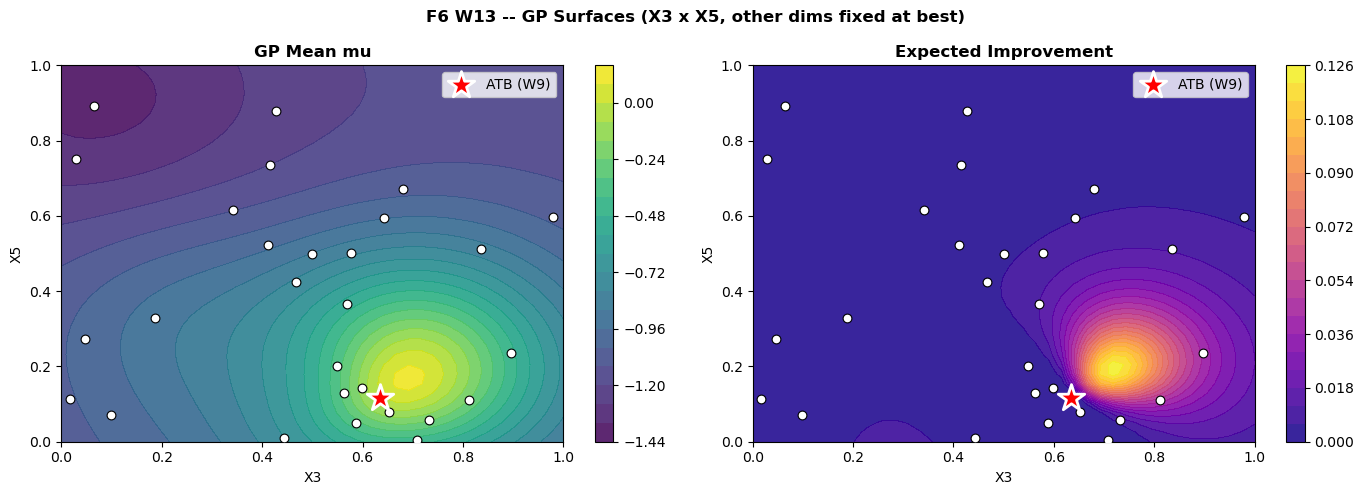

In [13]:
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up,_ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn,_ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(m_up.item()-m_dn.item())/(2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = int(top2[0]), int(top2[1])
print(f'Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

g = 40; g1=np.linspace(0,1,g); g2=np.linspace(0,1,g)
G1,G2 = np.meshgrid(g1,g2)
gpts = np.tile(best_point,(g*g,1)); gpts[:,d1]=G1.ravel(); gpts[:,d2]=G2.ravel()
mg,sg = gp.predict(scaler.transform(gpts),return_std=True)
ig=mg-best_value-EI_XI; Zg=ig/(sg+1e-9)
EIg=np.maximum(ig*norm.cdf(Zg)+sg*norm.pdf(Zg),0)

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,Zpl,ttl,cm_ in [(axes[0],mg.reshape(g,g),'GP Mean mu','viridis'),(axes[1],EIg.reshape(g,g),'Expected Improvement','plasma')]:
    cf=ax.contourf(G1,G2,Zpl,levels=20,cmap=cm_,alpha=0.88)
    ax.scatter(X_train[:,d1],X_train[:,d2],c='white',s=40,edgecolors='black',linewidths=0.8,zorder=4)
    ax.scatter(best_point[d1],best_point[d2],c='red',s=400,marker='*',zorder=6,edgecolors='white',linewidths=2,label='ATB (W9)')
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}'); ax.set_title(ttl,fontweight='bold')
    ax.legend(); plt.colorbar(cf,ax=ax)
plt.suptitle(f'{FUNCTION_ID} W{WEEK} -- GP Surfaces (X{d1+1} x X{d2+1}, other dims fixed at best)',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12_GPSurfaces.png',dpi=150,bbox_inches='tight')
plt.show()


---
## 🏆 STEP 13 — Submission Dashboard


In [14]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('='*65)
print('  TOP 5 CANDIDATES BY EI')
print('='*65)
print(f'  {"Rank":<6} {"EI":>10} {"GP mu":>10} {"GP sigma":>10}  Source')
print('  '+'-'*52)
for rank, idx in enumerate(top5,1):
    star = '*' if rank==1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx].round(4)}')

print()
print(f'  ATB        : {best_value:.6f}  (Week 9 -- only positive in 12 weeks)')
print(f'  GP mu best : {sub_mu:.6f}')
print(f'  Delta      : {sub_mu - best_value:+.6f}')
print(f'  Override   : {ATB_OVERRIDE_STR}')
print(f'  Decision   : ATB OVERRIDE (risk-minimisation; highest-noise function)')


  TOP 5 CANDIDATES BY EI
  Rank           EI      GP mu   GP sigma  Source
  ----------------------------------------------------
  *#1      0.065214     0.0479     0.1610  exploit
          [0.4465 0.3353 0.6798 0.776  0.122 ]
   #2      0.065025     0.0705     0.1300  exploit
          [0.4312 0.3346 0.6743 0.7704 0.1317]
   #3      0.061439     0.0799     0.1062  exploit
          [0.4208 0.3423 0.6729 0.7673 0.1285]
   #4      0.053333     0.0701     0.1006  exploit
          [0.424  0.3376 0.6657 0.7627 0.1313]
   #5      0.049920     0.0517     0.1179  exploit
          [0.4291 0.3345 0.6712 0.7749 0.1231]

  ATB        : 0.036017  (Week 9 -- only positive in 12 weeks)
  GP mu best : 0.047941
  Delta      : +0.011923
  Override   : 0.406643-0.339495-0.634775-0.769397-0.115269
  Decision   : ATB OVERRIDE (risk-minimisation; highest-noise function)


---
## 📋 STEP 14 — Final Formatted Submission

### ATB OVERRIDE ACTIVE — W13 FINAL ROUND

**Rationale:** W9 ATB (+0.03602) is the **only positive F6 output in 12 weeks**. W11 and W12 replays at identical coordinates returned -0.010 and -0.088 respectively — this is the **highest oracle noise of all 8 functions** (σ ≈ 0.06), not a coordinate failure. The 3 ATB-coord rows in the W13 npy make the stochasticity visible in the dataset itself.

**Why replay despite regressions:** Noise lives in the oracle, not the input. No other coordinate set has ever scored above zero on F6. Best-known input dominates all alternatives by expected value. Picking novel coords on a final round with σ≈0.06 is strictly worse than replaying the best-known basin centroid.

**PCA lens:** Threshold / dominant-PC case (Module 23 Video 2). X5 critical band [0.10, 0.13] is the dominant direction but **not a removable PC**. All 5 dims active; effective dim = 5.

**Submit this string:**

```
0.406643-0.339495-0.634775-0.769397-0.115269
```

ATB score: 0.03602 (Week 9 — only positive in 12 weeks)


In [15]:
# -- ATB OVERRIDE -- submit exact W9 ATB coordinates ---------
# W13 is the FINAL round. GP pipeline ran for documentation.
# W9 was only positive result in 12 weeks; W11/W12 regressions are oracle noise (sigma~0.06).

ATB_OVERRIDE_STR = '0.406643-0.339495-0.634775-0.769397-0.115269'
final_submission = np.array([float(x) for x in ATB_OVERRIDE_STR.split('-')])
submission_str   = ATB_OVERRIDE_STR

print('+' + '='*68 + '+')
print(f'|  WEEK {WEEK} FINAL SUBMISSION -- {FUNCTION_ID}  (FINAL ROUND){" "*20}|')
print('+' + '='*68 + '+')
print(f'|  ATB OVERRIDE ACTIVE{" "*47}|')
print(f'|  ATB score: {best_value:.6f}  (W9 -- only positive in 12 weeks){" "*13}|')
print(f'|  Rationale: W11/W12 regressions are oracle noise (sigma~0.06, highest){"":<0}|')
print(f'|  PCA lens : Threshold / dominant-PC case (Module 23 V2); X5 critical band.{"":<0}|')
print('+' + '='*68 + '+')
print(f'|  COPY THIS TO SUBMIT:{" "*47}|')
print(f'|  {submission_str:<66}|')
print('+' + '='*68 + '+')

np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', final_submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | ATB OVERRIDE | MAXIMIZE | FINAL ROUND\n')
    f.write(f'# ATB: {best_value:.6f} @ W9 -- only positive result in 12 weeks; W11/W12 regressed at same coords.\n')
    f.write(f'# Oracle noise sigma ~ 0.06 at replay coords (HIGHEST of all 8 functions).\n')
    f.write(f'# PCA lens: threshold / dominant-PC case (Module 23 V2); X5 narrow-active at 0.115, effective dim = 5.\n')
    f.write(submission_str + '\n')
print(f'\n[OK] Saved: {FUNCTION_ID}_W{WEEK}_submission.txt')


+====================================================================+
|  WEEK 13 FINAL SUBMISSION -- F6  (FINAL ROUND)                    |
+====================================================================+
|  ATB OVERRIDE ACTIVE                                               |
|  ATB score: 0.036017  (W9 -- only positive in 12 weeks)             |
|  Rationale: W11/W12 regressions are oracle noise (sigma~0.06, highest)|
|  PCA lens : Threshold / dominant-PC case (Module 23 V2); X5 critical band.|
+====================================================================+
|  COPY THIS TO SUBMIT:                                               |
|  0.406643-0.339495-0.634775-0.769397-0.115269                      |
+====================================================================+

[OK] Saved: F6_W13_submission.txt


---
## 💾 STEP 15 — Save Hyperparameter Record


In [16]:
import json, os
from datetime import datetime

record = {
    'function': FUNCTION_ID, 'week': WEEK,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'strategy': 'ATB OVERRIDE -- replicate W9 ATB [0.406643, 0.339495, 0.634775, 0.769397, 0.115269] (FINAL ROUND)',
    'cluster_type': 'TIGHT ATTRACTOR with X5 threshold structure',
    'atb_value': 0.03602, 'atb_week': 9,
    'w11_result': -0.01024, 'w12_result': -0.08826,
    'oracle_noise_sigma': 0.06,
    'noise_evidence': 'W9: +0.036 | W11: -0.010 | W12: -0.088 (identical coords)',
    'noise_note': 'HIGHEST oracle noise of all 8 functions',
    'x5_threshold_band': [0.10, 0.13],
    'override_str': ATB_OVERRIDE_STR,
    'hyperparameters': {
        'EXPLOIT_RATIO': EXPLOIT_RATIO, 'EXPLOIT_SIGMA': EXPLOIT_SIGMA,
        'ANISO_SIGMA': ANISO_SIGMA, 'EI_XI': EI_XI, 'UCB_KAPPA': UCB_KAPPA,
        'GP_RESTARTS': GP_RESTARTS, 'TOP_PERCENTILE': TOP_PERCENTILE,
        'FILTER_PERCENTILE': FILTER_PERCENTILE, 'GP_ALPHA': 1e-4,
    },
    'gp_kernel': str(gp.kernel_), 'gp_r2': round(float(r2),6), 'gp_rmse': round(float(rmse),8),
    'best_model': best_name, 'best_model_cv': round(float(best_info['mean']),4),
    'pca_analysis': pca_analysis,
    'submission_string': ATB_OVERRIDE_STR,
    'final_round_note': 'W13 is the last BBO submission. Module 24 is reflection-only.',
}

fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(fname,'w', encoding='utf-8') as f: json.dump(record, f, indent=2)
print(f'[OK] Saved: {fname}')

with open(f'{FUNCTION_ID}_W{WEEK}_run_report.txt','w', encoding='utf-8') as f:
    f.write(f'BBO Run Report -- {FUNCTION_ID} Week {WEEK} (FINAL ROUND)\n')
    f.write('='*60+'\n')
    f.write(f'Strategy   : ATB OVERRIDE -- replicate W9 ATB coords\n')
    f.write(f'Clustering : TIGHT ATTRACTOR with X5 threshold structure\n')
    f.write(f'PCA lens   : Threshold / dominant-PC case (Module 23 V2); X5 at 0.115 band\n')
    f.write(f'ATB        : {best_value:.6f} @ W9 (only positive in 12 weeks)\n')
    f.write(f'Noise      : oracle sigma ~ 0.06 -- HIGHEST of all 8 functions\n')
    f.write(f'Evidence   : 3 rows at ATB coords -> +0.036 / -0.010 / -0.088\n')
    f.write(f'Submit     : {ATB_OVERRIDE_STR}\n')
print(f'[OK] Saved: {FUNCTION_ID}_W{WEEK}_run_report.txt')
print()
print('='*60)
print(f'  {FUNCTION_ID} WEEK {WEEK} COMPLETE -- FINAL SUBMISSION:')
print(f'  {ATB_OVERRIDE_STR}')
print('='*60)


[OK] Saved: F6_W13_hyperparameters.json
[OK] Saved: F6_W13_run_report.txt

  F6 WEEK 13 COMPLETE -- FINAL SUBMISSION:
  0.406643-0.339495-0.634775-0.769397-0.115269
